# Traffic Demand Prediction

---
Pipeline: Config → Validation → Load → Schema → EDA → Leakage → Clean → Features → Aggregation → Encoding → CatBoost → LightGBM → Optuna → OOF → Ensemble → Final Training → Feature Importance → Submission

## 1. Project Configuration

In [ ]:
import os, sys, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Add project root to path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils import Config, validate_datasets, load_data, detect_schema, run_eda, clean_data, Timer, reduce_mem_usage
from src.feature_engineering import engineer_features
from src.encoding import apply_encodings
from src.aggregation import build_aggregation_features, build_memorization_features
from src.leakage_detection import detect_leakage
from src.training import (
    get_feature_columns, train_catboost_cv, train_lgbm_cv,
    optuna_catboost, optuna_lgbm,
    build_best_catboost_params, build_best_lgbm_params,
    predict_catboost, predict_lgbm,
    save_models, get_feature_importance
)
from src.ensemble import optimize_ensemble_weights, blend_predictions, generate_submission

Config.ensure_dirs()
Config.show_config()
print(f'\nPython {sys.version}')
print(f'NumPy {np.__version__}')
print(f'Pandas {pd.__version__}')

Configuration -> N_Folds: 5 | Seed: 42 | GPU: True

Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
NumPy 2.4.6
Pandas 3.0.3


## 2. Dataset Validation

In [2]:
validate_datasets()

## 3. Data Loading

In [3]:
train_raw, test_raw = load_data()
print(f'\nTrain columns: {list(train_raw.columns)}')
print(f'Test columns:  {list(test_raw.columns)}')
train_raw.head()

Datasets loaded -> Train: (77299, 11) | Test: (41778, 10)

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']
Test columns:  ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## 4. Automatic Schema Detection

In [4]:
schema = detect_schema(train_raw, test_raw)
TARGET = schema['target']
ID_COL = schema['id_column']
print(f'\nTarget: {TARGET}')
print(f'ID Column: {ID_COL}')

Detected target: demand | ID: Index
Features: 3 numerical | 4 categorical | 1 datetime | 1 geohash

Target: demand
ID Column: Index


## 5. Exploratory Data Analysis

Target stats:
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64
Train duplicate rows: 0


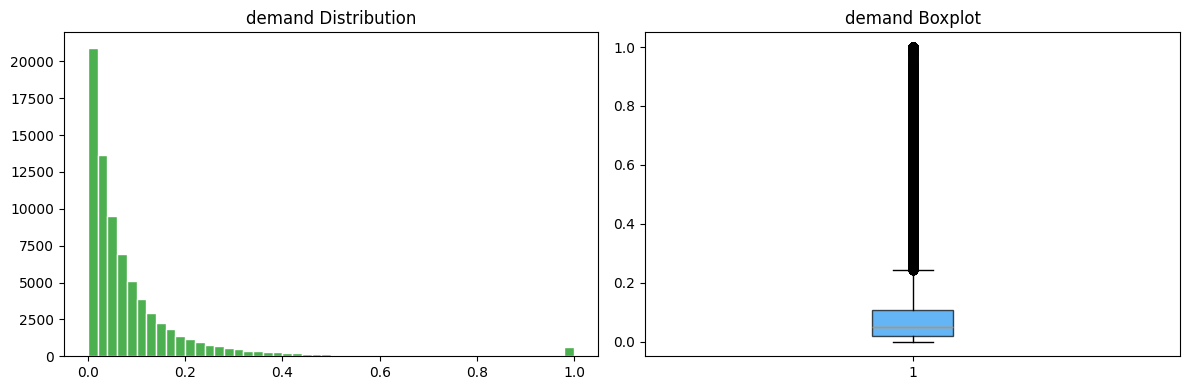

In [5]:
run_eda(train_raw, test_raw, schema)

## 6. Leakage Detection

In [6]:
leakage_findings = detect_leakage(train_raw, test_raw, schema)

Leakage Analysis -> Row Overlap: 0 rows (0.00%) | Shared timestamps: 47 (100.0%) | Shared geohashs: 1180 (99.2%)


## 7. Data Cleaning

In [7]:
train, test, schema = clean_data(train_raw.copy(), test_raw.copy(), schema)
print(f'\nPost-cleaning missing values (train): {train.isnull().sum().sum()}')
print(f'Post-cleaning missing values (test): {test.isnull().sum().sum()}')

Data cleaning -> Removed 0 duplicates | Final shape: (77299, 11)

Post-cleaning missing values (train): 0
Post-cleaning missing values (test): 0


## 8. Feature Engineering

In [8]:
with Timer('Feature Engineering'):
    train, test = engineer_features(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')

Feature Engineering -> Created 19 features | Final train shape: (77299, 30)
[Feature Engineering] Completed in 0.25s

Train shape: (77299, 30)
Test shape: (41778, 29)


## 9. Aggregation Features

In [9]:
with Timer('Aggregation Features'):
    train, test = build_aggregation_features(train, test, schema)
    train, test = build_memorization_features(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')

Aggregation Features -> Created 28 features from 7 groups | Final train shape: (77299, 58)
Memorization Features -> Created 4 features | Final train shape: (77299, 62)
[Aggregation Features] Completed in 0.29s

Train shape: (77299, 62)
Test shape: (41778, 61)


## 10. Target Encoding & Categorical Encoding

In [10]:
with Timer('Encoding'):
    train, test = apply_encodings(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')

# Reduce memory
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

Encoding -> Processed 8 categorical features | Final train shape: (77299, 83)
[Encoding] Completed in 0.82s

Train shape: (77299, 83)
Test shape: (41778, 82)


## 11. Prepare Features for Modeling

In [11]:
feature_cols = get_feature_columns(train, schema)
print(f'Number of features: {len(feature_cols)}')
print(f'Features: {feature_cols[:20]}...' if len(feature_cols) > 20 else f'Features: {feature_cols}')

y = train[TARGET].copy()
print(f'\nTarget stats:')
print(y.describe())

Number of features: 73
Features: ['day', 'NumberofLanes', 'Temperature', 'hour', 'minute', 'day_of_week', 'slot', 'is_rush_hour', 'sin_hour', 'cos_hour', 'sin_minute', 'cos_minute', 'sin_dow', 'cos_dow', 'latitude', 'longitude', 'geohash_len', 'Temperature_x_hour', 'lat_x_lon', 'Temperature_x_rush']...

Target stats:
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


## 12. CatBoost Training (Default Params)

In [12]:
with Timer('CatBoost Default CV'):
    cb_oof_default, cb_models_default, cb_scores_default = train_catboost_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS, use_gpu=Config.USE_GPU
    )
print(f'\nCatBoost Default CV R2: {np.mean(cb_scores_default):.6f}')

CatBoost 5-Fold CV: 5it [00:30,  6.10s/it]

CatBoost 5-Fold CV completed | Mean OOF R2: 0.995662 +/- 0.000550
[CatBoost Default CV] Completed in 30.50s

CatBoost Default CV R2: 0.995662


## 13. LightGBM Training (Default Params)

In [13]:
with Timer('LightGBM Default CV'):
    lgb_oof_default, lgb_models_default, lgb_scores_default = train_lgbm_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS, use_gpu=Config.USE_GPU
    )
print(f'\nLightGBM Default CV R2: {np.mean(lgb_scores_default):.6f}')

LightGBM 5-Fold CV: 5it [00:15,  3.05s/it]

LightGBM 5-Fold CV completed | Mean OOF R2: 0.992504 +/- 0.000822
[LightGBM Default CV] Completed in 15.25s

LightGBM Default CV R2: 0.992504


## 14. Optuna Hyperparameter Optimization

In [14]:
# CatBoost Optuna
with Timer('CatBoost Optuna'):
    cb_best_params, cb_best_score = optuna_catboost(
        train, y, feature_cols,
        n_trials=Config.OPTUNA_TRIALS,
        n_folds=Config.N_FOLDS,
        use_gpu=Config.USE_GPU
    )
print(f'\nCatBoost Optuna Best R2: {cb_best_score:.6f}')

CatBoost HPO -> Tuning 50 trials...


Best trial: 47. Best value: 0.995777: 100%|██████████| 50/50 [38:36<00:00, 46.33s/it]

CatBoost HPO -> Best OOF R2: 0.995777
[CatBoost Optuna] Completed in 2316.32s

CatBoost Optuna Best R2: 0.995777


In [15]:
# LightGBM Optuna
with Timer('LightGBM Optuna'):
    lgb_best_params, lgb_best_score = optuna_lgbm(
        train, y, feature_cols,
        n_trials=Config.OPTUNA_TRIALS,
        n_folds=Config.N_FOLDS,
        use_gpu=Config.USE_GPU
    )
print(f'\nLightGBM Optuna Best R2: {lgb_best_score:.6f}')

LightGBM HPO -> Tuning 50 trials...


Best trial: 34. Best value: 0.993104: 100%|██████████| 50/50 [24:09<00:00, 28.99s/it]

LightGBM HPO -> Best OOF R2: 0.993104
[LightGBM Optuna] Completed in 1449.39s

LightGBM Optuna Best R2: 0.993104


## 15. OOF Prediction Generation (Optimized Params)

In [16]:
# Retrain with best params
cb_opt_params = build_best_catboost_params(cb_best_params, use_gpu=Config.USE_GPU)
lgb_opt_params = build_best_lgbm_params(lgb_best_params, use_gpu=Config.USE_GPU)

print('CatBoost optimized params:'); print(json.dumps({k: str(v) for k,v in cb_opt_params.items()}, indent=2))
print('\nLightGBM optimized params:'); print(json.dumps({k: str(v) for k,v in lgb_opt_params.items()}, indent=2))

CatBoost optimized params:
{
  "loss_function": "RMSE",
  "eval_metric": "RMSE",
  "random_seed": "42",
  "verbose": "0",
  "allow_writing_files": "False",
  "learning_rate": "0.04754104935977362",
  "depth": "10",
  "iterations": "1100",
  "l2_leaf_reg": "1.4995672018446706",
  "bootstrap_type": "Bernoulli",
  "subsample": "0.975982728515173",
  "min_data_in_leaf": "2",
  "task_type": "GPU",
  "devices": "0"
}

LightGBM optimized params:
{
  "objective": "regression",
  "metric": "rmse",
  "verbosity": "-1",
  "random_state": "42",
  "n_jobs": "-1",
  "learning_rate": "0.011909804365410026",
  "num_leaves": "361",
  "n_estimators": "500",
  "reg_alpha": "0.049133127214236134",
  "reg_lambda": "1.3159517918892412",
  "subsample": "0.7822092205881002",
  "colsample_bytree": "0.6360598572931164",
  "min_child_samples": "31",
  "max_depth": "10",
  "device": "gpu",
  "gpu_platform_id": "0",
  "gpu_device_id": "0"
}


In [17]:
with Timer('CatBoost Optimized CV'):
    cb_oof, cb_models, cb_scores = train_catboost_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS,
        params=cb_opt_params, use_gpu=Config.USE_GPU
    )

with Timer('LightGBM Optimized CV'):
    lgb_oof, lgb_models, lgb_scores = train_lgbm_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS,
        params=lgb_opt_params, use_gpu=Config.USE_GPU
    )

print(f'\nCatBoost  Optimized CV R2: {np.mean(cb_scores):.6f} +/- {np.std(cb_scores):.6f}')
print(f'LightGBM  Optimized CV R2: {np.mean(lgb_scores):.6f} +/- {np.std(lgb_scores):.6f}')

# Save OOF predictions
np.save(str(Config.PRED_DIR / 'cb_oof.npy'), cb_oof)
np.save(str(Config.PRED_DIR / 'lgb_oof.npy'), lgb_oof)
print('\nOOF predictions saved.')

CatBoost 5-Fold CV: 5it [00:52, 10.58s/it]


CatBoost 5-Fold CV completed | Mean OOF R2: 0.995799 +/- 0.000459
[CatBoost Optimized CV] Completed in 52.90s


LightGBM 5-Fold CV: 5it [01:13, 14.66s/it]

LightGBM 5-Fold CV completed | Mean OOF R2: 0.993104 +/- 0.000977
[LightGBM Optimized CV] Completed in 73.31s

CatBoost  Optimized CV R2: 0.995799 +/- 0.000459
LightGBM  Optimized CV R2: 0.993104 +/- 0.000977

OOF predictions saved.


## 16. Ensemble Weight Optimization

In [18]:
best_weights, ensemble_r2 = optimize_ensemble_weights(
    [cb_oof, lgb_oof], y,
    model_names=['CatBoost', 'LightGBM']
)

print(f'\nFinal Ensemble Blend OOF R2: {ensemble_r2:.6f}')

CatBoost OOF R2: 0.995803
LightGBM OOF R2: 0.993123
Optimal weights -> CatBoost: 0.7000, LightGBM: 0.3000 | Ensemble OOF R2: 0.996374

Final Ensemble Blend OOF R2: 0.996374


## 17. Final Training & Test Predictions

In [19]:
# Generate test predictions
print('\n--- Generating Test Predictions ---')
cb_test_preds = predict_catboost(cb_models, test, feature_cols)
lgb_test_preds = predict_lgbm(lgb_models, test, feature_cols)

# Blend
final_preds = blend_predictions([cb_test_preds, lgb_test_preds], best_weights)

print(f'\nCatBoost test preds: mean={cb_test_preds.mean():.4f}, std={cb_test_preds.std():.4f}')
print(f'LightGBM test preds: mean={lgb_test_preds.mean():.4f}, std={lgb_test_preds.std():.4f}')
print(f'Ensemble test preds: mean={final_preds.mean():.4f}, std={final_preds.std():.4f}')

# Save models
save_models(cb_models, lgb_models, Config.MODEL_DIR)

# Save CV scores
cv_results = {
    'catboost_cv_scores': cb_scores,
    'catboost_mean_r2': float(np.mean(cb_scores)),
    'lightgbm_cv_scores': lgb_scores,
    'lightgbm_mean_r2': float(np.mean(lgb_scores)),
    'ensemble_r2': float(ensemble_r2),
    'ensemble_weights': best_weights,
    'catboost_best_params': {k: str(v) for k, v in cb_opt_params.items()},
    'lightgbm_best_params': {k: str(v) for k, v in lgb_opt_params.items()}
}
with open(Config.OUTPUT_DIR / 'cv_results.json', 'w') as f:
    json.dump(cv_results, f, indent=2)
print('\nCV results saved.')


--- Generating Test Predictions ---

CatBoost test preds: mean=0.1057, std=0.1348
LightGBM test preds: mean=0.1153, std=0.1544
Ensemble test preds: mean=0.1086, std=0.1405
  Models saved to c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\outputs\models

CV results saved.


## 18. Feature Importance

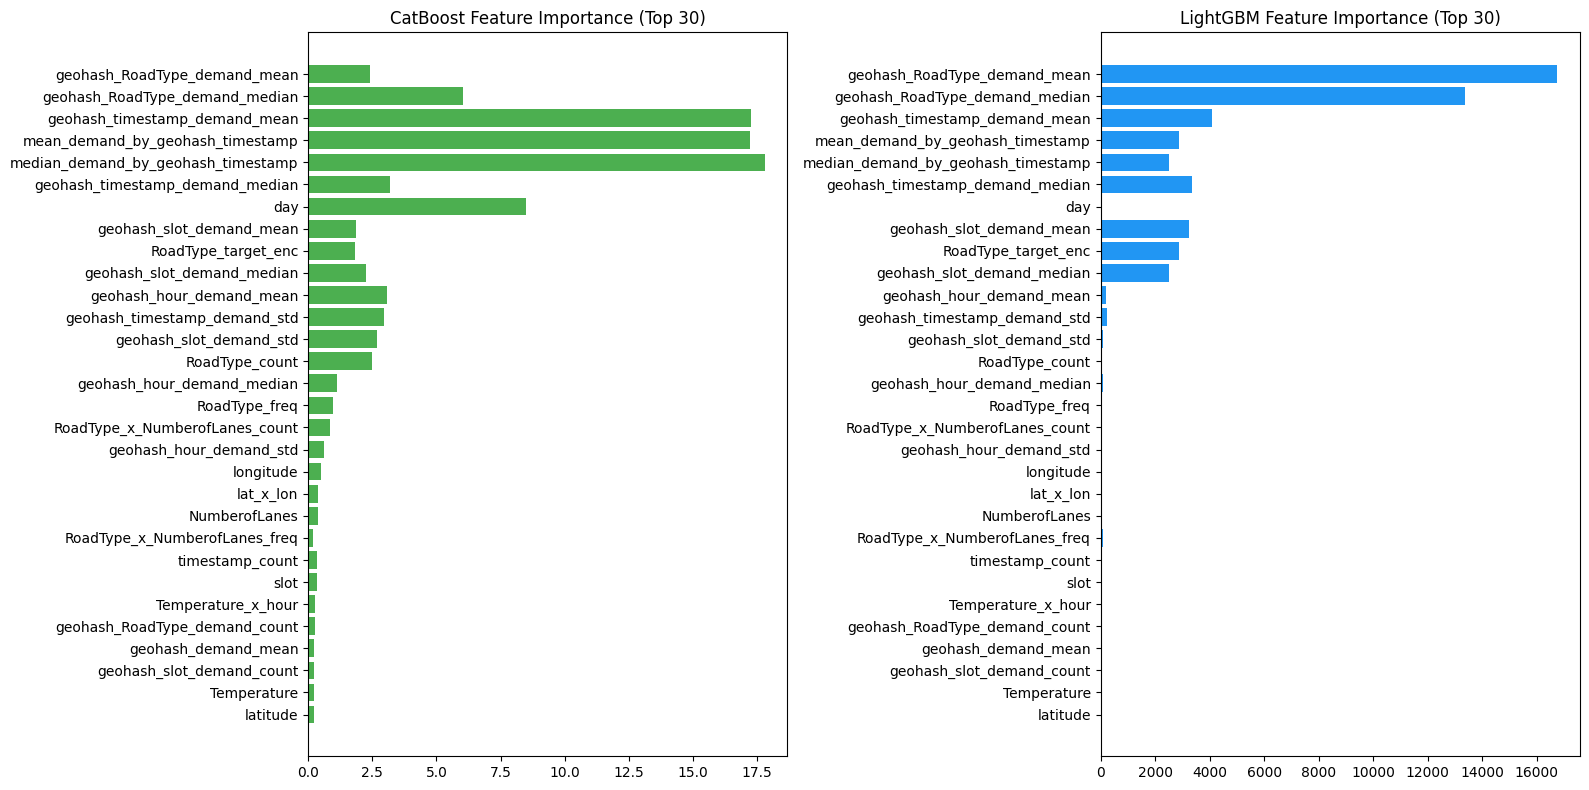


Top 15 Features:
                           feature  combined
      geohash_RoadType_demand_mean  0.171412
    geohash_RoadType_demand_median  0.157620
     geohash_timestamp_demand_mean  0.125275
  mean_demand_by_geohash_timestamp  0.113495
median_demand_by_geohash_timestamp  0.112937
   geohash_timestamp_demand_median  0.047638
                               day  0.042883
          geohash_slot_demand_mean  0.040098
               RoadType_target_enc  0.036312
        geohash_slot_demand_median  0.035135
          geohash_hour_demand_mean  0.017135
      geohash_timestamp_demand_std  0.016946
           geohash_slot_demand_std  0.014179
                    RoadType_count  0.012828
        geohash_hour_demand_median  0.006346


In [20]:
importance_df = get_feature_importance(cb_models, lgb_models, feature_cols)
importance_df.to_csv(Config.OUTPUT_DIR / 'feature_importance.csv', index=False)
print('\nTop 15 Features:')
print(importance_df[['feature', 'combined']].head(15).to_string(index=False))

## 19. Submission Generation

In [21]:
submission_path = Config.SUB_DIR / Config.SUBMISSION_FILENAME
submission = generate_submission(
    final_preds, test, ID_COL, 'demand', submission_path
)

submission.to_csv(Config.PROJECT_ROOT / 'submission.csv', index=False)
print('\nModel Execution Summary:')
print(f'  CatBoost Mean OOF R2:  {np.mean(cb_scores):.6f}')
print(f'  LightGBM Mean OOF R2:  {np.mean(lgb_scores):.6f}')
print(f'  Ensemble Blend OOF R2: {ensemble_r2:.6f}')
print(f'  Optimal Blend Weights: CatBoost={best_weights[0]:.4f}, LightGBM={best_weights[1]:.4f}')
print(f'  Submission Rows:       {len(submission)}')

Submission saved to c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\outputs\submissions\submission.csv | Shape: (41778, 2)

Model Execution Summary:
  CatBoost Mean OOF R2:  0.995799
  LightGBM Mean OOF R2:  0.993104
  Ensemble Blend OOF R2: 0.996374
  Optimal Blend Weights: CatBoost=0.7000, LightGBM=0.3000
  Submission Rows:       41778
